In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

# Расшифровка колонок — MMM_MMM_Comptage

Данные: подсчёт транспортных средств на дорогах агломерации Монпелье (MMM).

**Сокращения в названиях колонок:**
- **MJA** = Moyenne Journalière Annuelle — среднесуточный трафик за год
- **JO** = Jours Ouvrables — рабочие дни
- **JOHVS** = Jours Ouvrables Hors Vacances Scolaires — рабочие дни вне школьных каникул
- **TCJ** = Tous les Jours — все дни (включая выходные и праздники)
- **PL** = Poids Lourds — грузовые ТС (фуры, грузовики)
- **HP** = Heure de Pointe — час пик
- **HPM** = Heure de Pointe Matin — утренний час пик
- **HPS** = Heure de Pointe Soir — вечерний час пик
- **HCJ** = Heure Creuse Jour — дневное межпиковое время
- **HCN** = Heure Creuse Nuit — ночное межпиковое время

---

## Идентификаторы и метаданные станции

| Колонка | Описание |
|---|---|
| `objectid` | Уникальный идентификатор записи |
| `id_centrale` | ID счётной станции |
| `code_centrale` | Код счётной станции |
| `libelle_centrale` | Название / описание местоположения счётной станции |
| `annee` | Год измерения |
| `libelle_groupage` | Метка группировки направлений (например, «Sens cumulés» = суммарный поток) |
| `label_sens_circu` | Метка направления движения (откуда → куда) |
| `type_compteur` | Тип счётчика: `compteur tournant` — переносной, `compteur feux` — на светофоре, `compteur ponctuel` — точечный |
| `type_comptage` | Тип подсчёта: `bidirectionnel` — двунаправленный, `unidirectionnel` — однонаправленный |
| `nb_canaux` | Количество каналов (полос/направлений) у данной станции |
| `list_canaux` | Список кодов каналов (0, 1 — направления; Z — сумма) |
| `nb_annee` | Количество лет, за которые есть данные по станции |
| `list_annee` | Список лет, за которые есть данные |
| `code_canal` | Код текущего канала (0 или 1 — конкретное направление, Z — суммарный поток) |
| `descriptif_periode` | Период измерения (дата начала — дата конца) |
| `time_days` | Продолжительность периода измерения в днях |

---

## Интенсивность потока (авт./сут.)

| Колонка | Описание |
|---|---|
| `mja_jo` | Среднесуточный трафик — рабочие дни |
| `mja_johvs` | Среднесуточный трафик — рабочие дни вне школьных каникул |
| `mja_tcj` | Среднесуточный трафик — все дни |
| `mja_pl_tcj` | Среднесуточный трафик грузовых ТС — все дни |
| `mja_pl_johvs` | Среднесуточный трафик грузовых ТС — рабочие дни вне школьных каникул |

---

## Часы пик (JOHVS)

| Колонка | Описание |
|---|---|
| `hp_johvs_matin` | Утренний час пик: интенсивность (авт./ч) и временной интервал, например `96 (11h30 - 12h30)` |
| `hp_johvs_soir` | Вечерний час пик: интенсивность (авт./ч) и временной интервал |

---

## Трафик по периодам суток (авт./ч, JOHVS)

| Колонка | Описание |
|---|---|
| `hpm_0709_johvs` | Утренний час пик 07:00–09:00 — все ТС |
| `hpm_pl_0709_johvs` | Утренний час пик 07:00–09:00 — грузовые ТС |
| `hcj_0916_johvs` | Дневное межпиковое время 09:00–16:00 — все ТС |
| `hcj_pl_0916_johvs` | Дневное межпиковое время 09:00–16:00 — грузовые ТС |
| `hps_1619_johvs` | Вечерний час пик 16:00–19:00 — все ТС |
| `hps_pl_1619_johvs` | Вечерний час пик 16:00–19:00 — грузовые ТС |
| `hcn_1907_johvs` | Ночное время 19:00–07:00 — все ТС |
| `hcn_pl_1907_johvs` | Ночное время 19:00–07:00 — грузовые ТС |

---

## Скорость и доля грузовых ТС (TCJ)

| Колонка | Описание |
|---|---|
| `tir_tcj` | Доля грузовых ТС в потоке, % — все дни |
| `v85ma_tcj` | Скорость 85-го перцентиля в утренний час пик, км/ч — все дни |
| `vtma_tcj` | Средняя скорость в утренний час пик, км/ч — все дни |

---

## Атрибуты дороги (OpenStreetMap)

| Колонка | Описание |
|---|---|
| `name` | Название улицы / дороги (из OSM) |
| `highway` | Тип дороги по классификации OSM (`primary`, `secondary`, `tertiary`, `residential` и др.) |
| `nom_commune` | Название коммуны (муниципалитета) |
| `osm_id` | Идентификатор объекта в OpenStreetMap |

In [2]:
!ls -a

.                  .git               data               map_coverage.html
..                 .ipynb_checkpoints data_audit.ipynb
.DS_Store          .venv              geoloc_audit.ipynb


In [3]:
data = pd.read_csv("data/MMM_MMM_Comptage (1).csv")

In [11]:
data.columns.to_list()

['objectid',
 'id_centrale',
 'code_centrale',
 'libelle_centrale',
 'annee',
 'libelle_groupage',
 'label_sens_circu',
 'type_compteur',
 'type_comptage',
 'nb_canaux',
 'list_canaux',
 'nb_annee',
 'list_annee',
 'code_canal',
 'mja_jo',
 'mja_johvs',
 'mja_tcj',
 'mja_pl_tcj',
 'hp_johvs_matin',
 'hp_johvs_soir',
 'tir_tcj',
 'v85ma_tcj',
 'vtma_tcj',
 'mja_pl_johvs',
 'hpm_0709_johvs',
 'hpm_pl_0709_johvs',
 'hcj_0916_johvs',
 'hcj_pl_0916_johvs',
 'hps_1619_johvs',
 'hps_pl_1619_johvs',
 'hcn_1907_johvs',
 'hcn_pl_1907_johvs',
 'descriptif_periode',
 'time_days',
 'name',
 'highway',
 'nom_commune',
 'osm_id']

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12211 entries, 0 to 12210
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   objectid            12211 non-null  int64  
 1   id_centrale         12211 non-null  int64  
 2   code_centrale       12211 non-null  int64  
 3   libelle_centrale    12211 non-null  str    
 4   annee               12211 non-null  int64  
 5   libelle_groupage    12211 non-null  str    
 6   label_sens_circu    12211 non-null  str    
 7   type_compteur       12211 non-null  str    
 8   type_comptage       12211 non-null  str    
 9   nb_canaux           12211 non-null  int64  
 10  list_canaux         12211 non-null  str    
 11  nb_annee            12211 non-null  int64  
 12  list_annee          12211 non-null  str    
 13  code_canal          12211 non-null  str    
 14  mja_jo              12172 non-null  float64
 15  mja_johvs           12056 non-null  float64
 16  mja_tcj        

#### Сколько всего уникальных сечений

In [6]:
data["osm_id"].nunique()

2081

#### Сколько всего записей

In [7]:
data.drop_duplicates().shape[0]

12211

#### Какая доля записей имеет непустой id_osm. Именно эта доля определяет, сколько постов мы сможем автоматически привязать к сети в модуле 4.

In [31]:
data["osm_id"].isna().sum()

np.int64(0)

#### Свежесть: распределение по годам измерения. Сколько сечений измерено после 2020 года? Данные 2013 года для калибровки на 2024-й использовать нельзя.

In [32]:
data["annee"].value_counts()

annee
2023    1683
2022    1360
2026    1160
2024    1065
2021     933
2020     910
2018     767
2019     743
2025     641
2017     596
2016     504
2013     409
2014     407
2015     395
2012     261
2010     225
2011     152
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, '2010'),
  Text(1, 0, '2011'),
  Text(2, 0, '2012'),
  Text(3, 0, '2013'),
  Text(4, 0, '2014'),
  Text(5, 0, '2015'),
  Text(6, 0, '2016'),
  Text(7, 0, '2017'),
  Text(8, 0, '2018'),
  Text(9, 0, '2019'),
  Text(10, 0, '2020'),
  Text(11, 0, '2021'),
  Text(12, 0, '2022'),
  Text(13, 0, '2023'),
  Text(14, 0, '2024'),
  Text(15, 0, '2025'),
  Text(16, 0, '2026')])

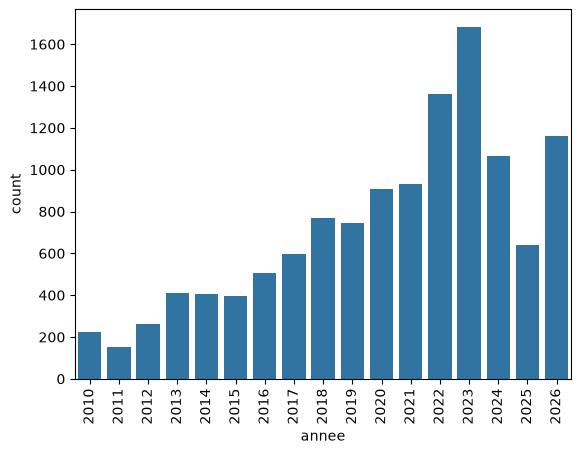

In [33]:
plt.figure()
sns.countplot(data=data, x="annee")
plt.xticks(rotation=90)

In [34]:
data[data["annee"] > 2020]["osm_id"].nunique()

1426

In [35]:
data["osm_id"].nunique()

2081

#### Полнота по периодам: у скольких сечений заполнены пиковые значения, а не только суточные. Калибровка по пикам содержательнее, чем по суткам.

In [36]:
peak_cols = [
    "hp_johvs_matin",
    "hp_johvs_soir",
    "hpm_0709_johvs",
    "hpm_pl_0709_johvs",
    "hps_1619_johvs",
    "hps_pl_1619_johvs",
]

peak_fill_rate = (
    data.groupby("osm_id")[peak_cols]
    .apply(lambda g: g.notna().sum() / len(g))
    .reset_index()
)
peak_fill_rate.columns = ["osm_id"] + [f"{c}_fill_rate" for c in peak_cols]
peak_fill_rate

Task was destroyed but it is pending!
task: <Task pending name='Task-176' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/artyomkholodkov/Desktop/matsim_analysis/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-177' coro=<Kernel.shell_main() running at /Users/artyomkholodkov/Desktop/matsim_analysis/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/artyomkholodkov/Desktop/matsim_analysis/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/artyomkholodkov/Desktop/matsim_analysis/.venv/lib/python3.14/site-packages/pandas/core/dtypes/cast.py:1330: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  if lib.dtypes_all_equal(list(types)):
Task was destroyed but it is pending!
task: <Task pending name='Task-177' coro=<Kernel.shell_main() running at /Users/artyomkholodkov/Desktop/matsim_analys

,osm_id,hp_johvs_matin_fill_rate,hp_johvs_soir_fill_rate,hpm_0709_johvs_fill_rate,hpm_pl_0709_johvs_fill_rate,hps_1619_johvs_fill_rate,hps_pl_1619_johvs_fill_rate
0,-6455414,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
1,-5604751,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,4082887,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
3,4218768,0.909091,0.909091,0.909091,0.000000,0.909091,0.000000
4,4296699,0.727273,0.727273,0.727273,0.545455,0.727273,0.545455
...,...,...,...,...,...,...,...
2076,1396542031,0.666667,0.666667,0.666667,0.000000,0.666667,0.000000
2077,1413501952,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2078,1415342430,0.800000,0.800000,0.800000,0.000000,0.800000,0.000000
2079,1415343204,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667


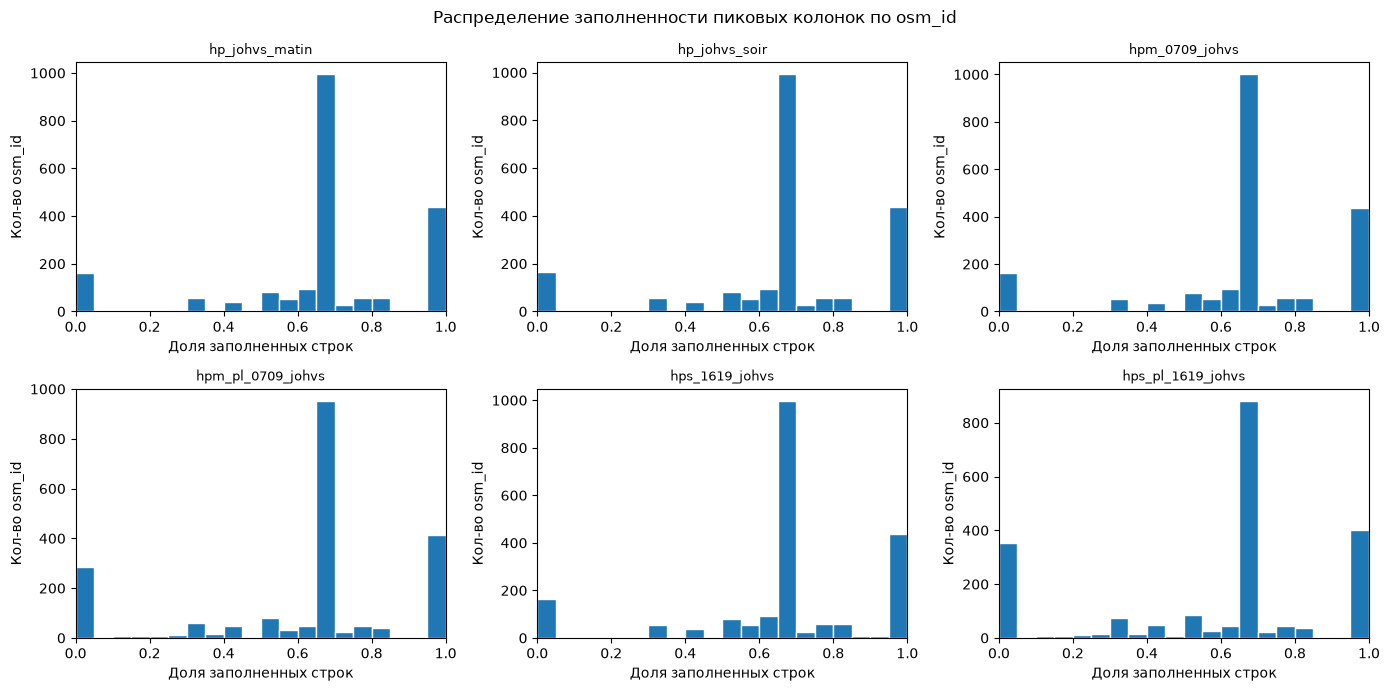

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, peak_cols):
    fill_col = f"{col}_fill_rate"
    ax.hist(peak_fill_rate[fill_col], bins=20, range=(0, 1), edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Доля заполненных строк")
    ax.set_ylabel("Кол-во osm_id")
    ax.set_xlim(0, 1)

fig.suptitle("Распределение заполненности пиковых колонок по osm_id", fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
peak_fill_rate.iloc[:, 1:].mean(axis=0)

hp_johvs_matin_fill_rate       0.667720
hp_johvs_soir_fill_rate        0.666921
hpm_0709_johvs_fill_rate       0.668776
hpm_pl_0709_johvs_fill_rate    0.611946
hps_1619_johvs_fill_rate       0.668429
hps_pl_1619_johvs_fill_rate    0.585156
dtype: float64

In [39]:
data["osm_id"].unique()

array([244106263, 370743659,  34201206, ..., 237104466, 392881418,
       602740846], shape=(2081,))

In [40]:
data[data["osm_id"] == 370743659].sort_values(by="annee")

,objectid,id_centrale,code_centrale,libelle_centrale,annee,libelle_groupage,label_sens_circu,type_compteur,type_comptage,nb_canaux,list_canaux,nb_annee,list_annee,code_canal,mja_jo,mja_johvs,mja_tcj,mja_pl_tcj,hp_johvs_matin,hp_johvs_soir,tir_tcj,v85ma_tcj,vtma_tcj,mja_pl_johvs,hpm_0709_johvs,hpm_pl_0709_johvs,hcj_0916_johvs,hcj_pl_0916_johvs,hps_1619_johvs,hps_pl_1619_johvs,hcn_1907_johvs,hcn_pl_1907_johvs,descriptif_periode,time_days,name,highway,nom_commune,osm_id
5913,5630,972,100457,MONTPELLIER. Boulevard de Strasbourg,2021,Comte Melgueil_Palavas,Comte Melgueil_Palavas,compteur feux,comptage unidirectionnel,1,{0},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",0,3819.0,3878.0,3601.0,NaN,255 (8h00 - 9h00),378 (17h00 - 18h00),NaN,NaN,NaN,NaN,209.0,NaN,235.0,NaN,338.0,NaN,67.0,NaN,du 01/01/2021 au 31/12/2021,364.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4552,5633,972,100457,MONTPELLIER. Boulevard de Strasbourg,2022,Sens cumulés,Sens cumulés,compteur feux,comptage bidirectionnel,3,"{0,1,Z}",11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",Z,4023.0,4074.0,3838.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 01/01/2022 au 23/06/2022,173.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4553,5631,972,100457,MONTPELLIER. Boulevard de Strasbourg,2022,Comte Melgueil_Palavas,Comte Melgueil_Palavas,compteur feux,comptage bidirectionnel,3,"{0,1,Z}",11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",0,3687.0,3725.0,3533.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,212.0,NaN,NaN,NaN,NaN,NaN,du 01/01/2022 au 23/06/2022,173.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4554,5632,972,100457,MONTPELLIER. Boulevard de Strasbourg,2022,Palavas_Comte Melgueil,Palavas_Comte Melgueil,compteur feux,comptage bidirectionnel,3,"{0,1,Z}",11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,336.0,349.0,305.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,du 27/09/2022 au 31/12/2022,95.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
2872,5634,972,100457,MONTPELLIER. Boulevard de Strasbourg,2023,Palavas_Comte Melgueil,Palavas_Comte Melgueil,compteur feux,comptage unidirectionnel,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,369.0,392.0,337.0,NaN,43 (8h00 - 9h00),30 (17h00 - 18h00),NaN,NaN,NaN,NaN,32.0,NaN,22.0,NaN,28.0,NaN,8.0,NaN,du 01/01/2023 au 31/12/2023,364.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4516,7689,83500,98341,MONTPELLIER. Boulevard de Strasbourg (CPEV),2023,Palavas_Orient,Palavas_Orient,compteur ponctuel,comptage unidirectionnel,1,{0},2,"{2023,2026}",0,379.0,379.0,337.0,NaN,54 (8h00 - 9h00),29 (16h00 - 17h00),NaN,36.0,25.0,NaN,40.0,1.0,22.0,1.0,26.0,0.0,6.0,0.0,du 23/11/2023 au 29/11/2023,6.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
1804,5635,972,100457,MONTPELLIER. Boulevard de Strasbourg,2024,Palavas_Comte Melgueil,Palavas_Comte Melgueil,compteur feux,comptage unidirectionnel,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,579.0,593.0,512.0,NaN,83 (8h00 - 9h00),49 (17h00 - 18h00),NaN,NaN,NaN,NaN,60.0,NaN,30.0,NaN,45.0,NaN,11.0,NaN,du 01/01/2024 au 31/12/2024,365.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
1162,5636,972,100457,MONTPELLIER. Boulevard de Strasbourg,2025,Palavas_Comte Melgueil,Palavas_Comte Melgueil,compteur feux,comptage unidirectionnel,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,674.0,712.0,604.0,NaN,98 (8h00 - 9h00),58 (17h00 - 18h00),NaN,NaN,NaN,NaN,70.0,NaN,36.0,NaN,53.0,NaN,14.0,NaN,du 01/01/2025 au 31/12/2025,364.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
3,5637,972,100457,MONTPELLIER. Boulevard de Strasbourg,2026,Palavas_Comte Melgueil,Palavas_Comte Melgueil,compteur feux,comptage unidirectionnel,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,754.0,779.0,671.0,NaN,113 (8h00 - 9h00),62 (17h00 - 18h00),NaN,NaN,NaN,NaN,79.0,NaN,39.0,NaN,56.0,NaN,15.0,NaN,du 01/01/2026 au 02/08/2026,213.0,Boulevard de Strasbourg,t

#### у скольких сечений заполнены суточные значения

In [41]:
daily_cols = [
    "mja_jo",
    "mja_johvs",
    "mja_tcj",
    "mja_pl_tcj",
    "mja_pl_johvs",
]

daily_fill_rate = (
    data.groupby("osm_id")[daily_cols]
    .apply(lambda g: g.notna().sum() / len(g))
    .reset_index()
)
daily_fill_rate.columns = ["osm_id"] + [f"{c}_fill_rate" for c in daily_cols]
daily_fill_rate

,osm_id,mja_jo_fill_rate,mja_johvs_fill_rate,mja_tcj_fill_rate,mja_pl_tcj_fill_rate,mja_pl_johvs_fill_rate
0,-6455414,1.0,1.0,1.0,1.000000,1.000000
1,-5604751,1.0,1.0,1.0,1.000000,1.000000
2,4082887,1.0,1.0,1.0,0.000000,0.000000
3,4218768,1.0,1.0,1.0,0.000000,0.000000
4,4296699,1.0,1.0,1.0,0.454545,0.454545
...,...,...,...,...,...,...
2076,1396542031,1.0,1.0,1.0,0.000000,0.000000
2077,1413501952,1.0,1.0,1.0,1.000000,1.000000
2078,1415342430,1.0,1.0,1.0,0.000000,0.000000
2079,1415343204,1.0,1.0,1.0,1.000000,1.000000


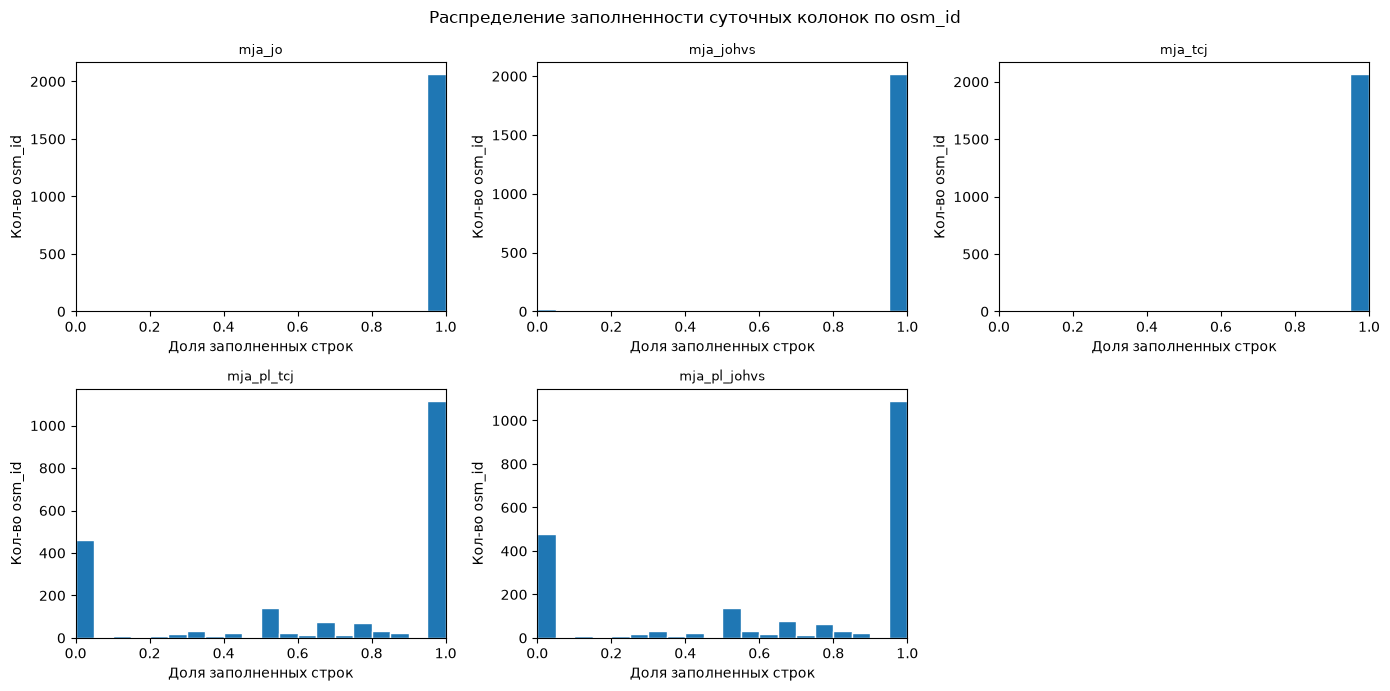

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, daily_cols):
    fill_col = f"{col}_fill_rate"
    ax.hist(daily_fill_rate[fill_col], bins=20, range=(0, 1), edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Доля заполненных строк")
    ax.set_ylabel("Кол-во osm_id")
    ax.set_xlim(0, 1)

axes[-1].set_visible(False)

fig.suptitle("Распределение заполненности суточных колонок по osm_id", fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
daily_fill_rate.iloc[:, 1:].mean(axis=0)

mja_jo_fill_rate          0.996772
mja_johvs_fill_rate       0.985598
mja_tcj_fill_rate         0.997133
mja_pl_tcj_fill_rate      0.674846
mja_pl_johvs_fill_rate    0.664047
dtype: float64

#### Автоматические / ручные: N / N

In [23]:
osm_types = data.groupby("osm_id").agg(detector_type=("type_compteur", "unique"))["detector_type"]

In [25]:
osm_types.value_counts()

detector_type
[compteur ponctuel]                                       1843
[compteur permanent]                                        56
[compteur feux]                                             55
[compteur permanent vélo]                                   46
[compteur tournant]                                         39
[compteur ponctuel vélo]                                     9
[compteur feux, compteur ponctuel]                           1
[compteur feux, compteur ponctuel]                           1
[compteur ponctuel, compteur feux]                           1
[compteur tournant, compteur ponctuel]                       1
[compteur tournant, compteur ponctuel]                       1
[compteur feux, compteur ponctuel]                           1
[compteur feux, compteur ponctuel]                           1
[compteur feux, compteur ponctuel]                           1
[compteur feux, compteur ponctuel]                           1
[compteur ponctuel, compteur feux]       

In [20]:
data[data["osm_id"] == 7984344]

,objectid,id_centrale,code_centrale,libelle_centrale,annee,libelle_groupage,label_sens_circu,type_compteur,type_comptage,nb_canaux,list_canaux,nb_annee,list_annee,code_canal,mja_jo,mja_johvs,mja_tcj,mja_pl_tcj,hp_johvs_matin,hp_johvs_soir,tir_tcj,v85ma_tcj,vtma_tcj,mja_pl_johvs,hpm_0709_johvs,hpm_pl_0709_johvs,hcj_0916_johvs,hcj_pl_0916_johvs,hps_1619_johvs,hps_pl_1619_johvs,hcn_1907_johvs,hcn_pl_1907_johvs,descriptif_periode,time_days,name,highway,nom_commune,osm_id
85,1427,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2026,Sens cumulés,Sens cumulés,compteur feux,comptage bidirectionnel,3,"{0,1,Z}",2,"{2025,2026}",Z,15193.0,15353.0,14562.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 01/01/2026 au 02/08/2026,213.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
86,1425,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2026,Boutonnet_Saint Charles,Boutonnet_Saint Charles,compteur feux,comptage bidirectionnel,3,"{0,1,Z}",2,"{2025,2026}",0,7862.0,7918.0,7500.0,NaN,500 (8h00 - 9h00),519 (17h00 - 18h00),NaN,NaN,NaN,NaN,475.0,NaN,445.0,NaN,516.0,NaN,190.0,NaN,du 01/01/2026 au 02/08/2026,213.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
87,1426,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2026,Boutonnet_Jugan,Boutonnet_Jugan,compteur feux,comptage bidirectionnel,3,"{0,1,Z}",2,"{2025,2026}",1,7331.0,7435.0,7062.0,NaN,477 (7h00 - 8h00),472 (16h00 - 17h00),NaN,NaN,NaN,NaN,459.0,NaN,452.0,NaN,464.0,NaN,161.0,NaN,du 01/01/2026 au 02/08/2026,213.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
1206,1423,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2025,Boutonnet_Saint Charles,Boutonnet_Saint Charles,compteur feux,comptage unidirectionnel,2,"{0,1}",2,"{2025,2026}",0,8149.0,8360.0,7855.0,NaN,521 (8h00 - 9h00),569 (16h00 - 17h00),NaN,NaN,NaN,NaN,495.0,NaN,476.0,NaN,552.0,NaN,196.0,NaN,du 08/07/2025 au 31/12/2025,176.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
1207,1424,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2025,Boutonnet_Jugan,Boutonnet_Jugan,compteur feux,comptage unidirectionnel,2,"{0,1}",2,"{2025,2026}",1,6993.0,6972.0,6783.0,NaN,454 (7h00 - 8h00),449 (14h00 - 15h00),NaN,NaN,NaN,NaN,430.0,NaN,426.0,NaN,422.0,NaN,155.0,NaN,du 07/07/2025 au 31/12/2025,177.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
2932,10447,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2023,Sens cumulés,Sens cumulés,compteur ponctuel,comptage bidirectionnel,3,"{0,1,Z}",3,"{2013,2018,2023}",Z,15350.0,15564.0,14741.0,33.0,NaN,NaN,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 09/06/2023 au 16/06/2023,7.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
2933,10446,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2023,Boutonnet_Lucie,Boutonnet_Lucie,compteur ponctuel,comptage bidirectionnel,3,"{0,1,Z}",3,"{2013,2018,2023}",1,8541.0,8541.0,8309.0,24.0,520 (7h30 - 8h30),551 (16h15 - 17h15),34.0,36.0,22.0,30.0,487.0,2.0,459.0,2.0,536.0,0.0,229.0,1.0,du 09/06/2023 au 16/06/2023,7.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
2934,10445,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2023,Lucie_Boutonnet,Lucie_Boutonnet,compteur ponctuel,comptage bidirectionnel,3,"{0,1,Z}",3,"{2013,2018,2023}",0,6809.0,7023.0,6432.0,9.0,440 (11h30 - 12h30),476 (17h30 - 18h30),9.0,28.0,17.0,13.0,390.0,2.0,411.0,1.0,459.0,0.0,166.0,0.0,du 04/07/2023 au 11/07/2023,7.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
8530,10444,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2018,Sens cumulés,Sens cumulés,compteur ponctuel,comptage bidirectionnel,3,"{0,1,Z}",3,"{2013,2018,2023}",Z,17148.0,17148.0,16227.0,153.0,NaN,NaN,NaN,NaN,NaN,173.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 16/01/2018 au 25/01/2018,9.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
8531,10443,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2018,Boutonnet_Lucie,Boutonnet_Lucie,compteur ponctuel,comptage bidirectionnel,3,"{0,1,Z}",3,"{2013,2018,2023}",1,10570.0,10570.0,10016.0,51.0,778 (7h45 - 8h45),731 (

#### Метод измерения: доля автоматических против ручных. Все методы - автоматические

#### Метод измерения (`type_compteur`)

| Значение | Описание |
|---|---|
| `compteur ponctuel` | Точечный стационарный счётчик на перегоне вне перекрёстка (петля или радар). Непрерывные долгосрочные наблюдения. |
| `compteur permanent` | Постоянный стационарный счётчик для моторизованного транспорта. Работает круглогодично, передаёт данные в реальном времени. |
| `compteur tournant` | Переносной счётчик (пневматические трубки или радар). Временно устанавливается на участке, затем перемещается. Краткосрочные замеры. |
| `compteur feux` | Детектор петлевого типа, встроенный в дорожное полотно на регулируемом перекрёстке. Работает в связке со светофором. |
| `compteur permanent vélo` | Постоянный стационарный счётчик велосипедов. Аналог `compteur permanent`, но фиксирует только велотранспорт. |
| `compteur ponctuel vélo` | Точечный временный счётчик велосипедов. Аналог `compteur ponctuel` для велотранспорта. |

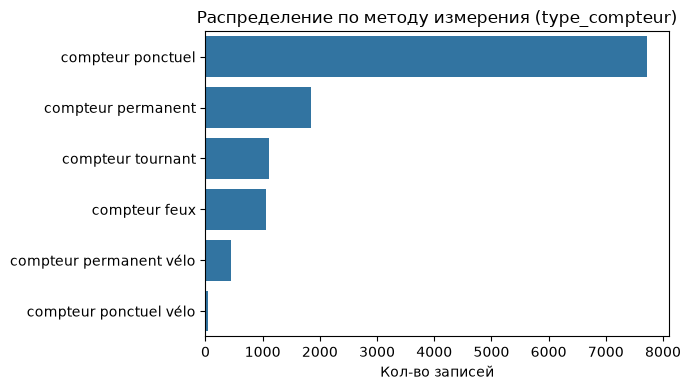

In [44]:
plt.figure(figsize=(7, 4))
order = data["type_compteur"].value_counts().index
sns.countplot(data=data, y="type_compteur", order=order)
plt.xlabel("Кол-во записей")
plt.ylabel("")
plt.title("Распределение по методу измерения (type_compteur)")
plt.tight_layout()
plt.show()

#### Направленность: значения по направлениям движения или суммарные по сечению? Связи в MATSim направленные, и если данные суммарные, при калибровке придётся складывать оба направления модели.

В основном значение трафика суммарные по сечению, но есть и только по направлениям в одну сторону. Распределение представлено ниже

In [56]:
data[["osm_id", "libelle_groupage", "label_sens_circu", "type_comptage", "nb_canaux", "list_canaux", "code_canal"]]

,osm_id,libelle_groupage,label_sens_circu,type_comptage,nb_canaux,list_canaux,code_canal
0,244106263,Sens cumulés,Sens cumulés,comptage bidirectionnel,3,"{0,1,Z}",Z
1,244106263,RM116E2_RM185,RM116E2_RM185,comptage bidirectionnel,3,"{0,1,Z}",0
2,244106263,RM185_RM116E2,RM185_RM116E2,comptage bidirectionnel,3,"{0,1,Z}",1
3,370743659,Palavas_Comte Melgueil,Palavas_Comte Melgueil,comptage unidirectionnel,1,{1},1
4,34201206,Sens cumulés,Sens cumulés,comptage bidirectionnel,3,"{0,1,Z}",Z
...,...,...,...,...,...,...,...
12206,295849662,Marès-Pérouse,Marès-Pérouse,comptage bidirectionnel,3,"{0,1,Z}",1
12207,295849662,Pérouse-Marès,Pérouse-Marès,comptage bidirectionnel,3,"{0,1,Z}",0
12208,27228047,Sens cumulés,Sens cumulés,comptage bidirectionnel,3,"{0,1,Z}",Z
12209,27228047,Impasse-Lepine,Impasse-Lepine,comptage bidirectionnel,3,"{0,1,Z}",0


In [54]:
data["type_comptage"].value_counts()

type_comptage
comptage bidirectionnel     10326
comptage unidirectionnel     1853
NR                             32
Name: count, dtype: int64

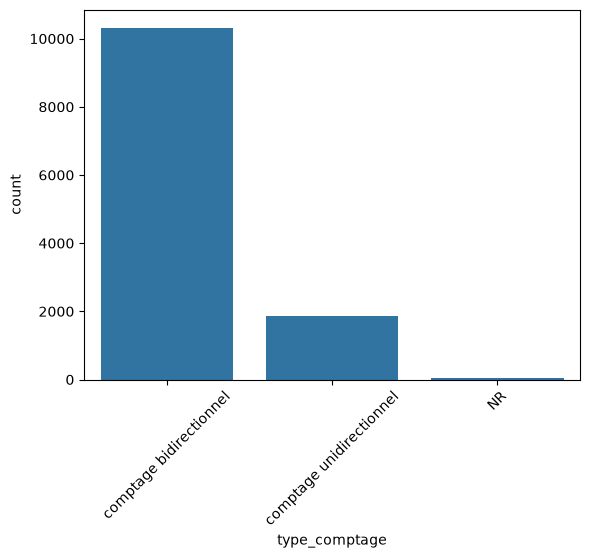

In [60]:
plt.figure()
sns.countplot(data=data, x="type_comptage")
plt.xticks(rotation=45)
plt.show()

#### Географическое покрытие: нанесите сечения на карту метрополии. Есть ли периферийные коммуны или всё сосредоточено в ядре Монпелье? Это определит, где модель будет калиброванной, а где — нет.

In [45]:
import requests
import folium
import time
from tqdm.notebook import tqdm

HEADERS = {"User-Agent": "matsim-analysis/1.0"}
BATCH = 200
RETRY_SLEEP = 10

osm_ids = data["osm_id"].unique().tolist()
batches = range(0, len(osm_ids), BATCH)

coords = {}
with tqdm(total=len(osm_ids), desc="Overpass API", unit="osm_id") as pbar:
    for i in batches:
        batch = osm_ids[i : i + BATCH]
        batch_ids = ",".join(str(x) for x in batch)
        query = f"[out:json];way(id:{batch_ids});out center;"

        for attempt in range(3):
            try:
                r = requests.post(
                    "https://overpass-api.de/api/interpreter",
                    data={"data": query},
                    headers=HEADERS,
                    timeout=60,
                )
                if r.status_code != 200 or not r.text.strip():
                    pbar.set_postfix(status=f"HTTP {r.status_code}, retry {attempt+1}")
                    time.sleep(RETRY_SLEEP)
                    continue
                for el in r.json().get("elements", []):
                    if "center" in el:
                        coords[el["id"]] = (el["center"]["lat"], el["center"]["lon"])
                pbar.set_postfix(status="ok", coords=len(coords))
                break
            except Exception as e:
                pbar.set_postfix(status=f"err: {e}, retry {attempt+1}")
                time.sleep(RETRY_SLEEP)

        pbar.update(len(batch))
        time.sleep(2)

print(f"Получено координат: {len(coords)} из {len(osm_ids)}")

Overpass API:   0%|          | 0/2081 [00:00<?, ?osm_id/s]

Получено координат: 1666 из 2081


In [46]:
commune_colors = {c: color for c, color in zip(
    data["nom_commune"].unique(),
    [f"#{hash(c) & 0xFFFFFF:06x}" for c in data["nom_commune"].unique()]
)}

m = folium.Map(location=[43.61, 3.88], zoom_start=11, tiles="CartoDB positron")

plotted = set()
for _, row in data[["osm_id", "nom_commune"]].drop_duplicates("osm_id").iterrows():
    oid = row["osm_id"]
    if oid not in coords:
        continue
    lat, lon = coords[oid]
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color=commune_colors.get(row["nom_commune"], "#888888"),
        fill=True,
        fill_opacity=0.7,
        popup=f"{oid} — {row['nom_commune']}",
        tooltip=row["nom_commune"],
    ).add_to(m)

m.save("map_coverage.html")
m

In [57]:
data["nom_commune"].nunique()

41

In [49]:
data["nom_commune"].value_counts() 

nom_commune
Montpellier                  7823
Castelnau-le-Lez              441
Lattes                        396
Saint-Jean-de-Védas           330
Le Crès                       252
Villeneuve-lès-Maguelone      206
Pignan                        203
Lavérune                      197
Fabrègues                     196
Vendargues                    191
Grabels                       189
Montferrier-sur-Lez           149
Baillargues                   144
Castries                      141
Cournonterral                 127
Juvignac                      121
Saint-Drézéry                 120
Cournonsec                    113
Pérols                        103
Jacou                          97
Clapiers                       90
Saint-Geniès-des-Mourgues      76
Montaud                        75
Saussan                        73
Saint-Brès                     56
Saint-Georges-d'Orques         52
Murviel-lès-Montpellier        52
Sussargues                     52
Restinclières                  45
Be

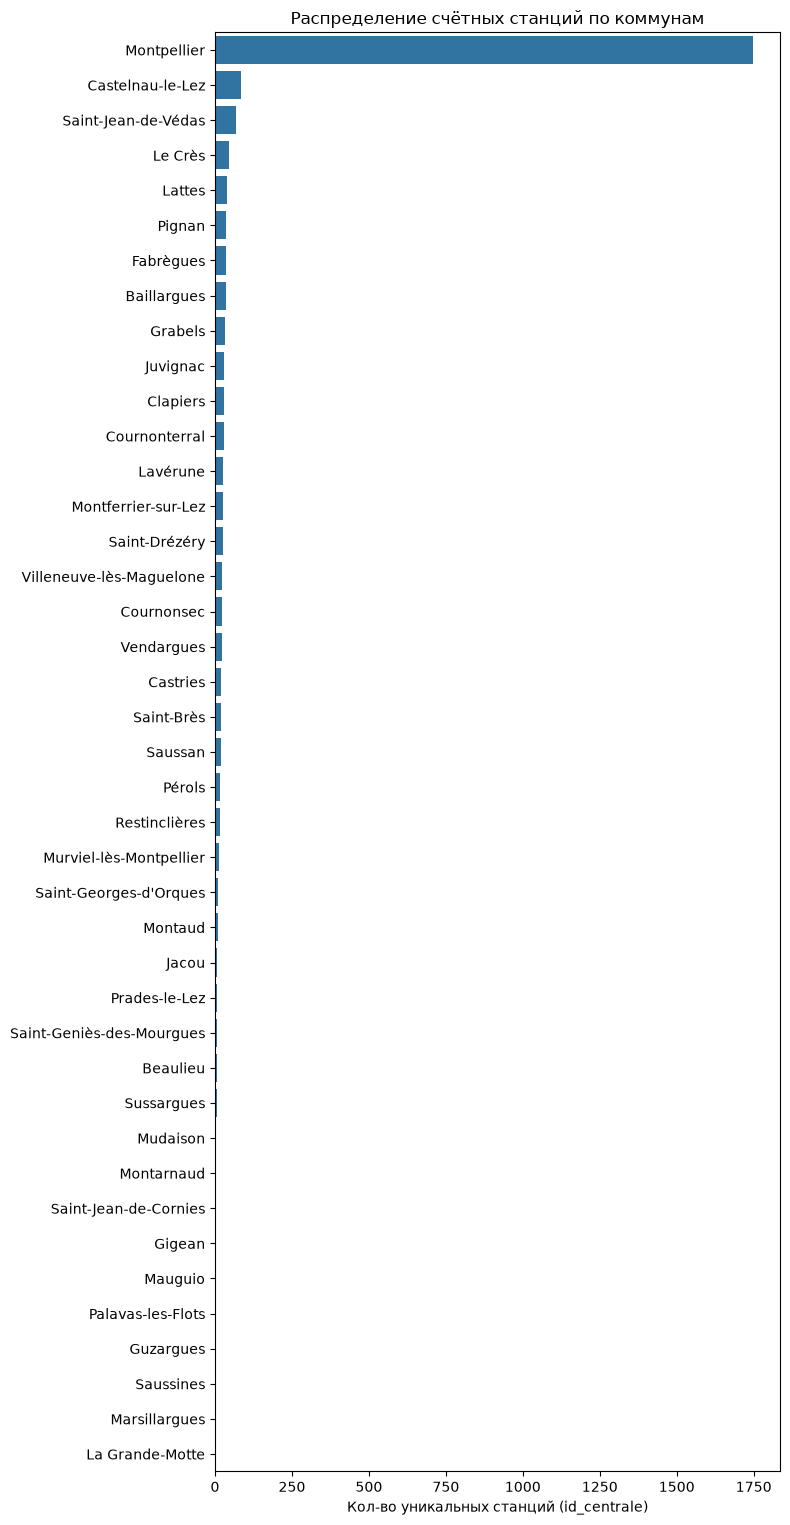

In [47]:
stations_per_commune = (
    data.drop_duplicates("id_centrale")["nom_commune"]
    .value_counts()
    .reset_index()
)
stations_per_commune.columns = ["nom_commune", "count"]

plt.figure(figsize=(8, len(stations_per_commune) * 0.35 + 1))
sns.barplot(data=stations_per_commune, y="nom_commune", x="count", order=stations_per_commune["nom_commune"])
plt.xlabel("Кол-во уникальных станций (id_centrale)")
plt.ylabel("")
plt.title("Распределение счётных станций по коммунам")
plt.tight_layout()
plt.show()